# Importing Libraries

In [138]:
# Core Data Manipulation
import numpy as np
import pandas as pd

# Machine Learning & Clustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Data Visualization
import matplotlib.pyplot as plt

# Geospatial Analysis
import geopandas as gpd


# Loading DF

In [139]:
norm_df = pd.read_csv('..\\Data\\NMF_ZIP.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\Modified Zip Code Tabulation Areas (MODZCTA).geojson")



# Clustering Hierarchical

In [140]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:\n", labels)
    print("===================")
    print("Value Counts:\n", labels.value_counts())


In [141]:
# Drop incident zip column
Features = norm_df.drop("Incident_Zip", axis=1)

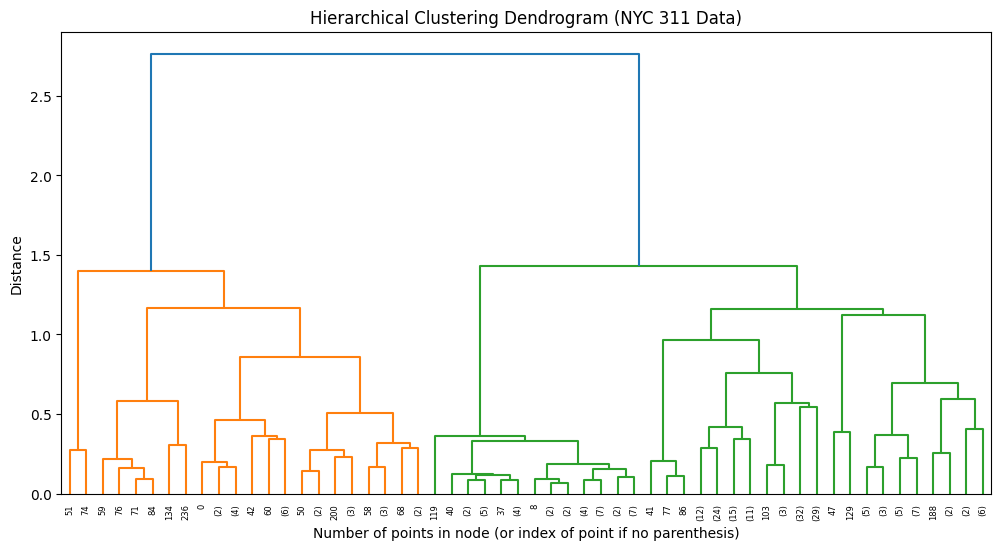

In [142]:
# Fitting the model 
agg = AgglomerativeClustering(
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
agg.fit(Features)

# Dendrogram plot func
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


# Plot the Dendrogram
plt.figure(figsize=(12, 6))
plot_dendrogram(agg, truncate_mode='level', p=6) # p is rendreing limit
plt.title("Hierarchical Clustering Dendrogram (NYC 311 Data)")
plt.xlabel("Number of points in node (or index of point if no parenthesis)")
plt.ylabel("Distance")
plt.show()


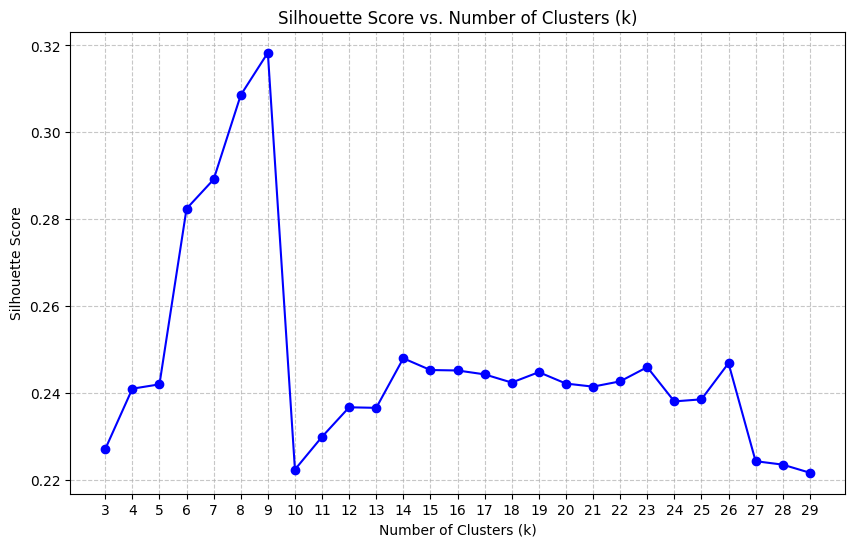

In [143]:
# Assuming 'Features' and 'pre_norm_df_final' are already defined

score_lst = []
k_range = range(3, 30) # Define the range once to keep it consistent

for k in k_range:
    # Get labels
    final_clustering = AgglomerativeClustering(n_clusters=k)
    labels = final_clustering.fit_predict(Features)
    norm_df['Cluster'] = labels

    # Calculate the Silhouette Score
    score = silhouette_score(Features, labels)
    score_lst.append(score)

# Create the x-axis list (number of clusters)
k_lst = list(k_range)    

# --- Make the plot ---
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(k_lst, score_lst, marker='o', linestyle='-', color='b') # Added points 'o' for visibility

# Add labels and title
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

# Formatting to make it look nice
plt.xticks(k_lst) # Shows every 'k' value on the x-axis
plt.grid(True, linestyle='--', alpha=0.7) # Adds a subtle grid

# Display the plot
plt.show()

We chose 3 clusters.

In [144]:
# Get labels
final_clustering = AgglomerativeClustering(n_clusters=3)
labels = pd.Series(final_clustering.fit_predict(Features))
norm_df['Cluster'] = labels
output(labels)

# Calculate the Silhouette Score
# It uses the original 'Features' array and the 'labels' predicted by your AgglomerativeClustering
score = silhouette_score(Features, labels)

# Print the result
print(f"Silhouette Score for 9 clusters: {score:.4f}")

The labels:
 0      0
1      1
2      1
3      1
4      0
      ..
234    1
235    1
236    0
237    1
238    1
Length: 239, dtype: int64
Value Counts:
 1    163
2     39
0     37
Name: count, dtype: int64
Silhouette Score for 9 clusters: 0.2272


In [145]:
vc = labels.value_counts()
vc

1    163
2     39
0     37
Name: count, dtype: int64

# Draw the results on a map

In [146]:
# Define the tiny outlier clusters we want to push to the end
vc = norm_df['Cluster'].value_counts()
outlier_clusters = singleton_labels = vc[vc == 1].index.tolist()

# Get a list of all current clusters in the dataframe, sorted numerically
current_clusters = sorted(norm_df['Cluster'].dropna().unique())

# Separate the "main" clusters from the "outlier" clusters
main_clusters = [c for c in current_clusters if c not in outlier_clusters]
outliers_present = [c for c in outlier_clusters if c in current_clusters]

# Create a new ordered list: Main clusters first, followed by outliers at the end
new_cluster_order = main_clusters + outliers_present

# Create a mapping dictionary {old_id: new_id}
# This automatically assigns 0, 1, 2... etc.
# The main clusters will become 0 to 10, and the outliers will become 11, 12, 13, 14.
cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(new_cluster_order)}

# Let's print the mapping so we can verify it worked as wanted
print("Here is how the clusters are being renumbered:")
for old, new in cluster_mapping.items():
    print(f"Old Cluster {old} --> New Cluster {new}")

# Apply the mapping to overwrite the old numbers
norm_df['Cluster'] = norm_df['Cluster'].map(cluster_mapping)

Here is how the clusters are being renumbered:
Old Cluster 0 --> New Cluster 0
Old Cluster 1 --> New Cluster 1
Old Cluster 2 --> New Cluster 2


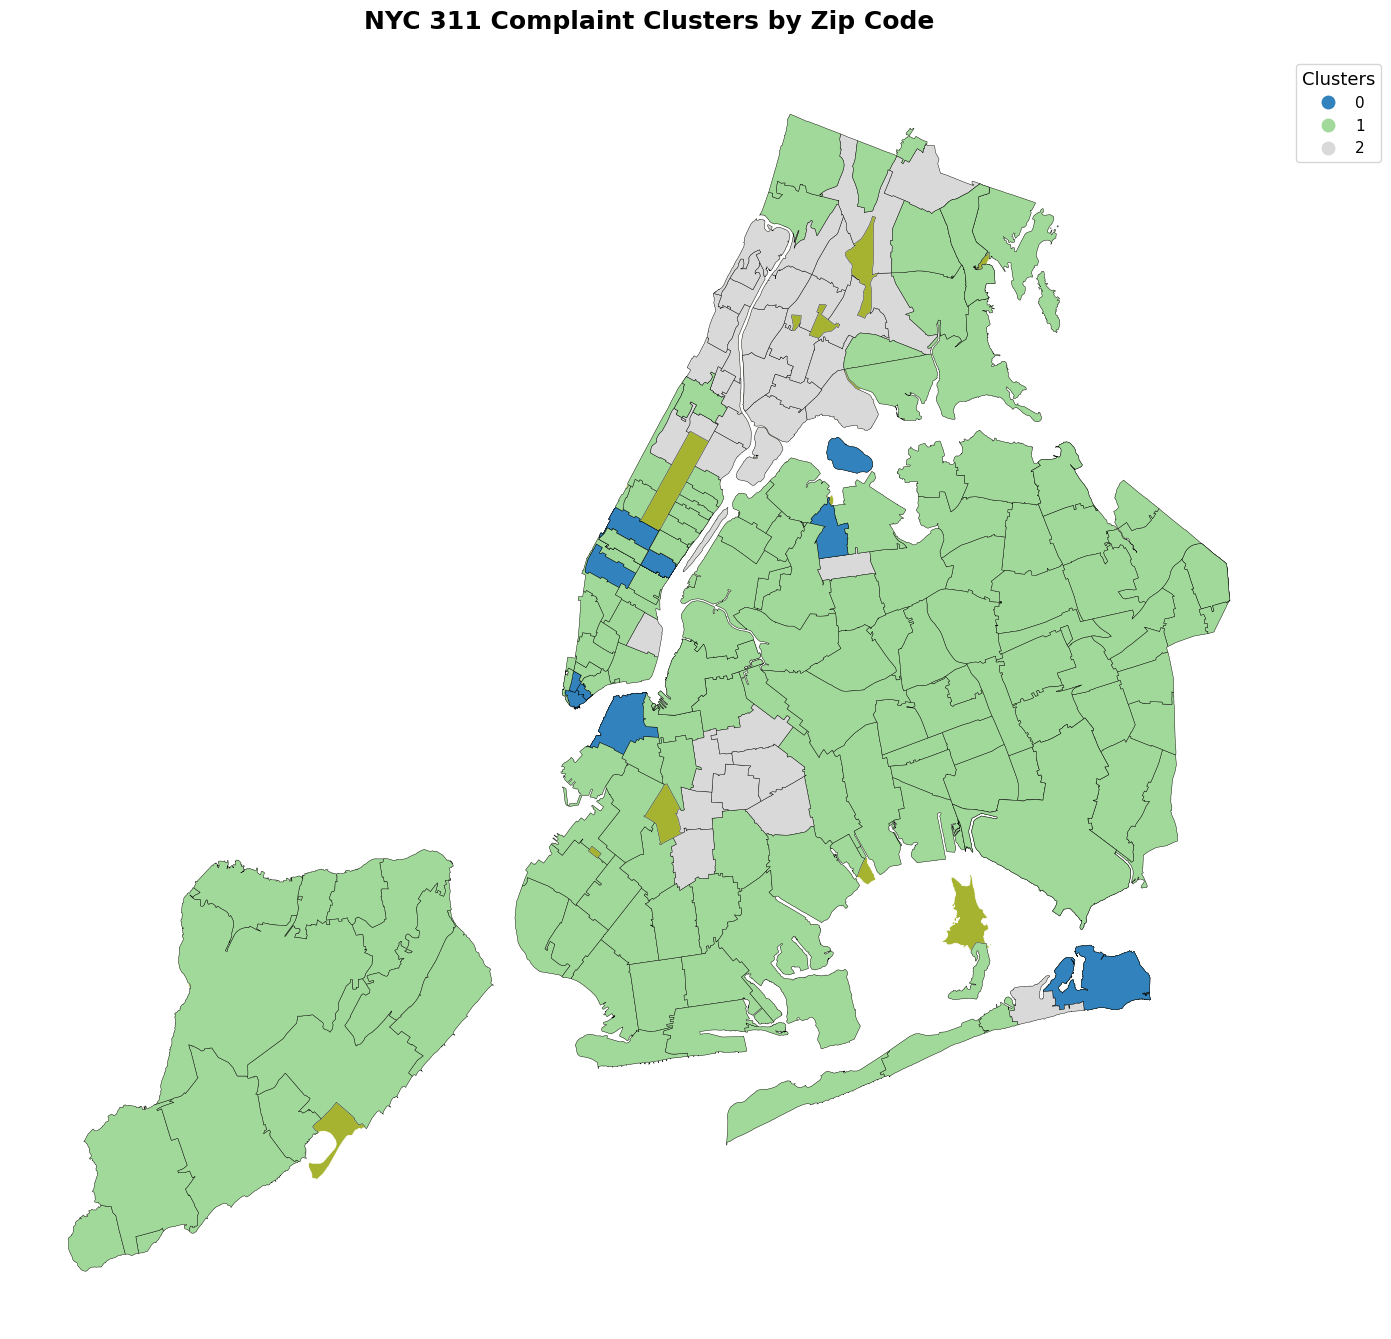

In [147]:
# Prepare the dataframe for the merge
pree_norm_df_final = norm_df.reset_index()

# Cleaning up zip codes to remove decimals and ensure standard format
pree_norm_df_final['Incident_Zip'] = (
    pree_norm_df_final['Incident_Zip']
    .astype(str)
    .str.split('.')
    .str[0]
    .str.zfill(5)
)
nyc_map['modzcta'] = nyc_map['modzcta'].astype(str).str.strip()

# This maps point/vanity zips, airports, splits, and former "trash" zips to their parent polygons (We sused an LLM to categorize the zips)
zip_crosswalk = {
    # Midtown Manhattan Vanity Zips
    '10118': '10001', '10119': '10001', '10120': '10001', '10121': '10001', 
    '10122': '10001', '10123': '10001', '10151': '10022', '10152': '10022', 
    '10153': '10022', '10154': '10022', '10155': '10022', '10165': '10017', 
    '10166': '10017', '10167': '10017', '10168': '10017', '10169': '10017', 
    '10170': '10017', '10171': '10017', '10172': '10017', '10173': '10017', 
    '10174': '10017', '10020': '10036', '10041': '10004', '10045': '10005', 
    '10048': '10007', '10055': '10022', '10080': '10007', '10103': '10019', 
    '10105': '10019', '10106': '10019', '10107': '10019', '10110': '10036', 
    '10111': '10036', '10112': '10036', '10115': '10027', '10158': '10017', 
    '10162': '10021', '10175': '10017', '10176': '10017', '10177': '10017', 
    '10178': '10017', '10179': '10017',
    
    # Financial District / Downtown
    '10271': '10005', '10278': '10007', '10279': '10007', '10281': '10280',
    
    # Brooklyn Zips & Splits
    '11249': '11211', '11241': '11201', '11242': '11201', '11251': '11201',
    
    # Queens / Airports / Special Facilities
    '11359': '11360', # Fort Totten
    '11371': '11370', # LaGuardia Airport
    '11430': '11434', # JFK Airport
    '11695': '11691', # Far Rockaway
    '11005': '11004', # Glen Oaks border

    # --- FORMER TRASH ZIPS INCORPORATED HERE ---
    
    # Bordering Nassau & Westchester Counties (Mapped to closest NYC neighborhood)
    '10803': '10475', # Pelham Manor -> mapped to Bronx border
    '11001': '11004', # Floral Park (Nassau) -> mapped to Floral Park (Queens)
    '11021': '11363', # Great Neck -> mapped to Little Neck
    '11040': '11004', # New Hyde Park -> mapped to Floral Park (Queens)
    '11096': '11691', # Inwood (Nassau) -> mapped to Far Rockaway
    '11803': '11426', # Plainview -> mapped to Bellerose (Eastern Queens edge)

    # NYC Vanity, Parks, and Error Defaults
    '00083': '10024', # Central Park -> mapped to Upper West Side
    '10000': '10001', # Generic NYC Error -> mapped to Midtown
    '10400': '10451', # Generic Bronx Error -> mapped to South Bronx

}

# Apply crosswalk maps
pree_norm_df_final['Incident_Zip'] = pree_norm_df_final['Incident_Zip'].replace(zip_crosswalk)


# Merge the geographic polygons with the clustering labels
mapped_clusters = nyc_map.merge(
    pree_norm_df_final, 
    left_on='modzcta', 
    right_on='Incident_Zip', 
    how='inner'
)

# Plot the Choropleth Map
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Plot a light grey base map of ALL NYC zip codes behind the data for context
nyc_map.plot(ax=ax, color="#a6b330", edgecolor='white', linewidth=0.5)

# Plot the specific clusters
mapped_clusters.plot(
    column='Cluster', 
    ax=ax, 
    categorical=True, 
    legend=True,
    cmap='tab20c',      # Switched to tab20 to easily handle up to 20 distinct categories
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'loc': 'upper left', 
        'bbox_to_anchor': (1, 1), 
        'title': "Clusters", 
        'fontsize': 11,
        'title_fontsize': 13
    }
)

plt.title('NYC 311 Complaint Clusters by Zip Code', fontsize=18, fontweight='bold', pad=20)
plt.axis('off') 
plt.tight_layout()
plt.show()

In [148]:
# Combine the features and the new hierarchical labels
features_with_labels = Features.copy()
features_with_labels['Cluster'] = labels

# Calculate the manual "centroids" (the mathematical average of each cluster)
hierarchical_centroids = features_with_labels.groupby('Cluster').mean()

# Reuse our persona analysis function
def analyze_hierarchical_personas(centroid_dataframe, top_n=3):
    """
    Identifies the top N driving features for each hierarchical cluster.
    """
    print(f"--- Top {top_n} Defining 311 Complaints per Hierarchical Cluster ---\n")
    
    # Iterate through the index (which now contains the cluster numbers 0 through 9)
    for cluster_id in centroid_dataframe.index:
        
        # Isolate the current cluster's averages
        cluster_profile = centroid_dataframe.loc[cluster_id]
        
        # Sort to find the highest dominating complaints
        top_features = cluster_profile.sort_values(ascending=False).head(top_n)
        
        print(f"Cluster {cluster_id}:")
        for feature, value in top_features.items():
            print(f"  * {feature}: {value:.4f}")
            
        print("-" * 40)

# Running the func
analyze_hierarchical_personas(hierarchical_centroids, top_n=4)

--- Top 4 Defining 311 Complaints per Hierarchical Cluster ---

Cluster 0:
  * Profile_7 (Street_and_Transportation_Pct): 0.3808
  * Profile_5 (Public_Order_and_Police_Pct): 0.1191
  * Profile_3 (Other/Misc_CType_Pct): 0.0990
  * Profile_6 (Weekend_Ratio): 0.0983
----------------------------------------
Cluster 1:
  * Profile_6 (Weekend_Ratio): 0.1293
  * Profile_1 (Street_and_Transportation_Pct): 0.1095
  * Profile_8 (Noise_Pct): 0.0869
  * Profile_7 (Street_and_Transportation_Pct): 0.0730
----------------------------------------
Cluster 2:
  * Profile_2 (Residential_and_Mixed_Use_Pct): 0.1897
  * Profile_8 (Noise_Pct): 0.1550
  * Profile_6 (Weekend_Ratio): 0.0656
  * Profile_7 (Street_and_Transportation_Pct): 0.0654
----------------------------------------
